In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./raw_data/raw_2.csv")
df.head()

,id,ts,target_ts,resource,input_value,predicted_value,actual_value,horizon_seconds,model_version
0,1,2026-03-06 16:51:20.155848+00,2026-03-06 16:52:20.155848+00,cpu,0.215692,0.216594,0.219101,60,v20260306-164606-2486
1,2,2026-03-06 16:51:20.214609+00,2026-03-06 16:52:20.214609+00,ram,70.085938,72.262680,71.964844,60,v20260306-164606-2486
2,3,2026-03-06 16:51:20.239225+00,2026-03-06 16:52:20.239225+00,rps,2139.520000,2159.550537,2282.080000,60,v20260306-164606-2486
3,4,2026-03-06 16:51:35.006147+00,2026-03-06 16:52:35.006147+00,cpu,0.127728,0.219829,0.214463,60,v20260306-164606-2486
4,5,2026-03-06 16:51:35.025183+00,2026-03-06 16:52:35.025183+00,ram,70.085938,71.133728,70.042969,60,v20260306-164606-2486


In [16]:
# Для однієї колонки
df['ts'] = pd.to_datetime(df['ts'])
print(df['ts'].dtype)

datetime64[ns, UTC]


In [41]:
save_df = df[
    (df['ts'] > '2026-03-06 22:00:00') & 
    (df['ts'] < '2026-03-07 07:00:00')
]

# 2. Assign the filtered columns back to the variable (if that's your goal)
save_df= save_df.sort_values(by='ts')
save_df.to_csv("./raw_data/raw_data_2.csv")

In [33]:
filter_cpu = df[
    (df["resource"] == "ram") & 
    (df['ts'] > '2026-03-06 22:00:00') & 
    (df['ts'] < '2026-03-07 07:00:00')
]

# 2. Assign the filtered columns back to the variable (if that's your goal)
filter_cpu= filter_cpu.sort_values(by='ts')

# 3. View the result
filter_cpu

,id,ts,target_ts,resource,input_value,predicted_value,actual_value,horizon_seconds,model_version
2849,2978,2026-03-06 22:00:07.132458+00:00,2026-03-06 22:01:07.132458+00,ram,28.121094,47.990898,28.121094,60,v20260306-_tuned_20260306-181039-0246
2852,2981,2026-03-06 22:00:22.150213+00:00,2026-03-06 22:01:22.150213+00,ram,28.121094,47.990791,28.121094,60,v20260306-_tuned_20260306-181039-0246
2855,2984,2026-03-06 22:00:37.148073+00:00,2026-03-06 22:01:37.148073+00,ram,28.367188,48.006069,28.121094,60,v20260306-_tuned_20260306-181039-0246
2858,2987,2026-03-06 22:00:52.185421+00:00,2026-03-06 22:01:52.185421+00,ram,28.121094,47.996788,28.121094,60,v20260306-_tuned_20260306-181039-0246
2861,2990,2026-03-06 22:01:07.163116+00:00,2026-03-06 22:02:07.163116+00,ram,28.121094,47.995621,28.121094,60,v20260306-_tuned_20260306-181039-0246
...,...,...,...,...,...,...,...,...,...
9658,9443,2026-03-07 06:58:51.767154+00:00,2026-03-07 06:59:51.767154+00,ram,31.136719,48.427940,30.511719,60,v20260306-_tuned_20260306-181039-0246
9599,9446,2026-03-07 06:59:06.762186+00:00,2026-03-07 07:00:06.762186+00,ram,31.136719,48.428272,30.511719,60,v20260306-_tuned_20260306-181039-0246
9661,9449,2026-03-07 06:59:21.762624+00:00,2026-03-07 07:00:21.762624+00,ram,31.136719,48.428509,30.511719,60,v20260306-_tuned_20260306-181039-0246
9602,9452,2026-03-07 06:59:36.768328+00:00,2026-03-07 07:00:36.768328+00,ram,31.136719,48.428654,30.511719,60,v20260306-_tuned_20260306-181039-0246


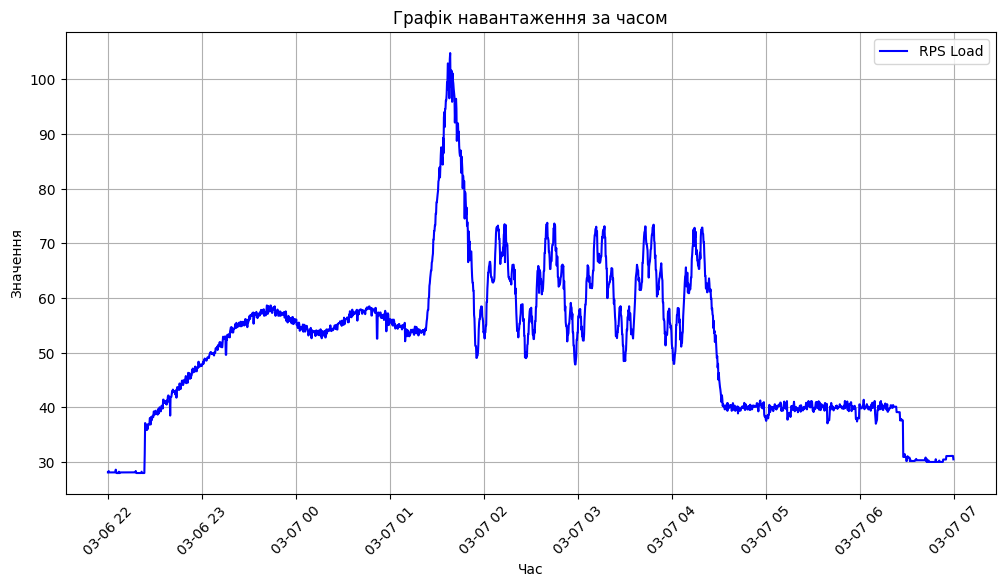

In [34]:
plt.figure(figsize=(12, 6)) # Розмір графіка
plt.plot(filter_cpu['ts'], filter_cpu['input_value'], label='RPS Load', color='blue')

plt.title('Графік навантаження за часом')
plt.xlabel('Час')
plt.ylabel('Значення')
plt.grid(True) # Додати сітку
plt.xticks(rotation=45) # Нахилити підписи часу, щоб вони не перекривалися
plt.legend()
plt.show()

In [40]:
len(filter_cpu)

2160

In [35]:
time_deltas = filter_cpu['ts'].diff()

# Подивимося на найбільші зазори
print(time_deltas.max())

0 days 00:00:17.469018


In [36]:
# Створюємо часовий поріг (20 секунд)
threshold = pd.Timedelta(seconds=16)

# Знаходимо всі рядки, де зазор більший за 20с
gaps = filter_cpu[time_deltas > threshold]

if gaps.empty:
    print("✅ Зазорів більше 20 секунд не знайдено.")
else:
    print(f"❌ Знайдено {len(gaps)} зазорів!")
    print(gaps[['ts']]) # Вивести моменти, де сталися розриви

❌ Знайдено 1 зазорів!
                                   ts
3263 2026-03-06 22:22:09.580821+00:00


In [39]:
# Створюємо допоміжну таблицю для аналізу розривів
analysis = pd.DataFrame({
    'gap_end': filter_cpu['ts'],
    'gap_start': filter_cpu['ts'].shift(1),
    'duration': filter_cpu['ts'].diff()
})

# Фільтруємо лише великі розриви
big_gaps = analysis[analysis['duration'] > pd.Timedelta(seconds=15)]

print(big_gaps)

                              gap_end                        gap_start  \
2852 2026-03-06 22:00:22.150213+00:00 2026-03-06 22:00:07.132458+00:00   
2858 2026-03-06 22:00:52.185421+00:00 2026-03-06 22:00:37.148073+00:00   
2871 2026-03-06 22:01:52.178304+00:00 2026-03-06 22:01:37.109239+00:00   
2876 2026-03-06 22:02:22.099062+00:00 2026-03-06 22:02:07.093619+00:00   
2879 2026-03-06 22:02:37.166277+00:00 2026-03-06 22:02:22.099062+00:00   
...                               ...                              ...   
9593 2026-03-07 06:58:06.781978+00:00 2026-03-07 06:57:51.762447+00:00   
9655 2026-03-07 06:58:21.793288+00:00 2026-03-07 06:58:06.781978+00:00   
9661 2026-03-07 06:59:21.762624+00:00 2026-03-07 06:59:06.762186+00:00   
9602 2026-03-07 06:59:36.768328+00:00 2026-03-07 06:59:21.762624+00:00   
9664 2026-03-07 06:59:51.776817+00:00 2026-03-07 06:59:36.768328+00:00   

                   duration  
2852 0 days 00:00:15.017755  
2858 0 days 00:00:15.037348  
2871 0 days 00:00:15.

🔄 Завантаження бойової моделі та скейлерів...
🚀 Симуляція реального часу (Inference Снайпера)...

📊 Метрики на Locust-тесті (АБСОЛЮТНІ ЗНАЧЕННЯ CPU):
 - CPU: MSE = 0.00071 | MAE = 0.01605


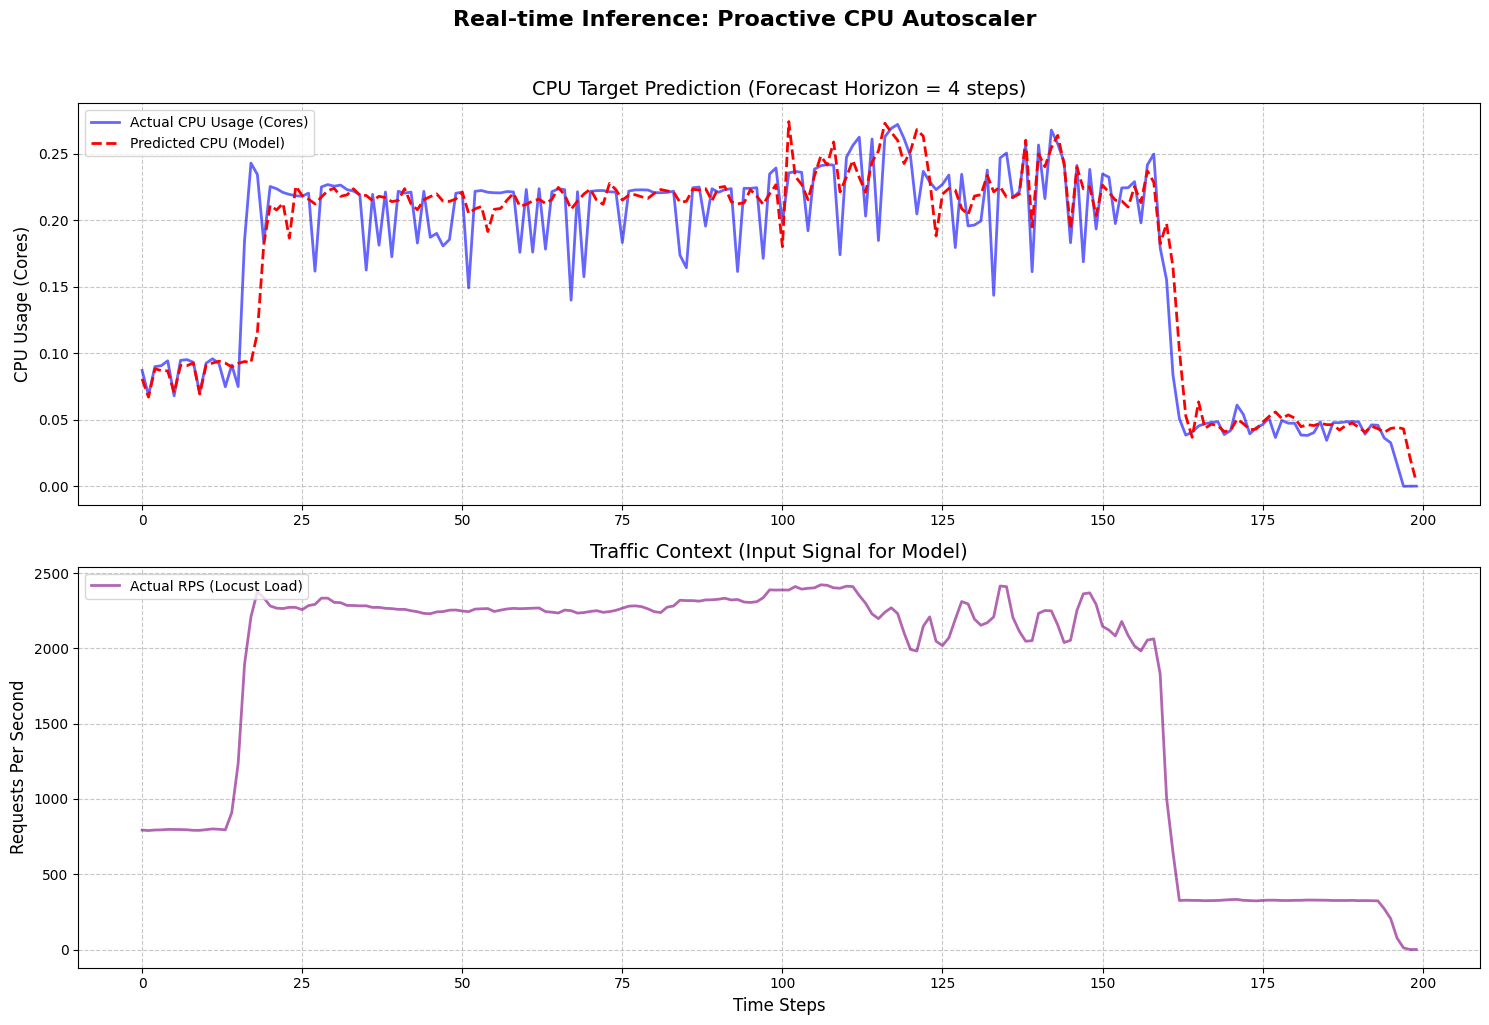

In [ ]:
import numpy as np
import pandas as pd
import pickle # Використовуємо pickle замість joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error



In [1]:
import os
import json
import shutil

# Шлях до директорії твого тюнера
tuner_dir = "k8s_tuning/final_autoscaler"

print("🔍 Скануємо директорію тюнера на наявність пошкоджених файлів...")
corrupted_trials = []

# Проходимося по всіх підпапках
for root, dirs, files in os.walk(tuner_dir):
    for file in files:
        if file == "trial.json":
            file_path = os.path.join(root, file)
            try:
                # Пробуємо прочитати JSON
                with open(file_path, 'r', encoding='utf-8') as f:
                    json.load(f)
            except (json.JSONDecodeError, ValueError):
                # Якщо зловили помилку - файл битий
                print(f"❌ Знайдено пошкоджений файл: {file_path}")
                corrupted_trials.append(root)

# Видаляємо знайдені зламані папки


🔍 Скануємо директорію тюнера на наявність пошкоджених файлів...
❌ Знайдено пошкоджений файл: k8s_tuning/final_autoscaler/trial_0297/trial.json


In [2]:
print(corrupted_trials)

['k8s_tuning/final_autoscaler/trial_0297']


In [3]:
for folder in corrupted_trials:
    print(f"🗑️ Видаляємо пошкоджену директорію експерименту: {folder}")
    shutil.rmtree(folder)

if not corrupted_trials:
    print("✅ Все чисто! Зламаних JSON файлів не знайдено.")
else:
    print("🚀 Готово! Сміття прибрано. Тепер можна безпечно перезапускати тюнер.")

🗑️ Видаляємо пошкоджену директорію експерименту: k8s_tuning/final_autoscaler/trial_0297
🚀 Готово! Сміття прибрано. Тепер можна безпечно перезапускати тюнер.


In [4]:
import json

oracle_file = "k8s_tuning/final_autoscaler/oracle.json"

try:
    with open(oracle_file, "r", encoding="utf-8") as f:
        oracle_data = json.load(f)
        
    print(f"🔍 Завислі спроби до очищення: {oracle_data.get('ongoing_trials')}")
    
    # Очищаємо список "завислих" спроб, які перервалися
    oracle_data["ongoing_trials"] = {}
    
    with open(oracle_file, "w", encoding="utf-8") as f:
        json.dump(oracle_data, f, indent=2)
        
    print("✅ oracle.json успішно виправлено! Тюнер більше не шукатиме видалену папку '0297'.")
except Exception as e:
    print(f"❌ Щось пішло не так: {e}")

🔍 Завислі спроби до очищення: {'tuner0': '0297'}
✅ oracle.json успішно виправлено! Тюнер більше не шукатиме видалену папку '0297'.


In [10]:
import os
import json
import shutil

tuner_dir = "k8s_tuning/final_autoscaler"
oracle_file = os.path.join(tuner_dir, "oracle.json")

print("🔍 Починаємо глибокий аудит результатів KerasTuner...\n")

valid_trials = {}
seen_hps = set()
duplicates_to_delete = []

# 1. Збираємо інформацію по всіх папках
for item in os.listdir(tuner_dir):
    if item.startswith("trial_") and os.path.isdir(os.path.join(tuner_dir, item)):
        trial_json_path = os.path.join(tuner_dir, item, "trial.json")
        
        if os.path.exists(trial_json_path):
            try:
                with open(trial_json_path, "r", encoding="utf-8") as f:
                    trial_data = json.load(f)
                
                # Створюємо унікальний "зліпок" (хєш) гіперпараметрів
                hp_values = trial_data["hyperparameters"]["values"]
                hp_tuple = tuple(sorted(hp_values.items()))
                
                # Перевіряємо статус та дублікати
                if trial_data.get("status") != "COMPLETED":
                    print(f"⏳ Незавершена спроба {item}. Йде під видалення.")
                    duplicates_to_delete.append(os.path.join(tuner_dir, item))
                elif hp_tuple in seen_hps:
                    print(f"🔄 Дублікат параметрів у {item}. Йде під видалення.")
                    duplicates_to_delete.append(os.path.join(tuner_dir, item))
                else:
                    # Це унікальна, успішна спроба
                    seen_hps.add(hp_tuple)
                    valid_trials[trial_data["trial_id"]] = trial_data
            except Exception as e:
                print(f"❌ Зламаний файл {trial_json_path}: {e}")
                duplicates_to_delete.append(os.path.join(tuner_dir, item))


# 3. Аналіз того, що залишилося
model_counts = {'lstm': 0, 'gru': 0, 'cnn': 0}
for t_id, t_data in valid_trials.items():
    m_type = t_data["hyperparameters"]["values"].get("model_type", "unknown")
    if m_type in model_counts:
        model_counts[m_type] += 1

print("\n📊 СТАТИСТИКА УНІКАЛЬНИХ ТА ЗАВЕРШЕНИХ СПРОБ:")
print(f" - LSTM: {model_counts['lstm']} / 96")
print(f" - GRU:  {model_counts['gru']} / 96")
print(f" - CNN:  {model_counts['cnn']} / 96")
print(f"Всього валідних: {len(valid_trials)} / 288")



🔍 Починаємо глибокий аудит результатів KerasTuner...

⏳ Незавершена спроба trial_0102. Йде під видалення.

📊 СТАТИСТИКА УНІКАЛЬНИХ ТА ЗАВЕРШЕНИХ СПРОБ:
 - LSTM: 102 / 96
 - GRU:  0 / 96
 - CNN:  0 / 96
Всього валідних: 102 / 288


In [7]:
import os
import json

tuner_dir = "k8s_tuning/final_autoscaler"

print("🕵️ Починаємо розслідування: Аналіз простору гіперпараметрів для GRU...\n")

gru_combinations = set()
param_ranges = {
    'units_gru': set(),
    'learning_rate': set(),
    'batch_size': set(),
    'dropout': set()
}

# 1. Скануємо всі файли trial.json
for item in os.listdir(tuner_dir):
    if item.startswith("trial_") and os.path.isdir(os.path.join(tuner_dir, item)):
        trial_json_path = os.path.join(tuner_dir, item, "trial.json")
        
        if os.path.exists(trial_json_path):
            try:
                with open(trial_json_path, "r", encoding="utf-8") as f:
                    data = json.load(f)
                
                # Беремо тільки успішні спроби
                if data.get("status") != "COMPLETED":
                    continue
                    
                hps = data["hyperparameters"]["values"]
                
                # Фільтруємо тільки GRU
                if hps.get("model_type") == "gru":
                    u = hps.get("units_gru")
                    lr = hps.get("learning_rate")
                    bs = hps.get("batch_size")
                    # Округлюємо dropout до 2 знаків, бо іноді float дає 0.20000000001
                    dp = round(hps.get("dropout", 0), 2) 
                    
                    # Зберігаємо комбінацію
                    gru_combinations.add((u, lr, bs, dp))
                    
                    # Зберігаємо унікальні значення для кожного параметра
                    if u is not None: param_ranges['units_gru'].add(u)
                    if lr is not None: param_ranges['learning_rate'].add(lr)
                    if bs is not None: param_ranges['batch_size'].add(bs)
                    if dp is not None: param_ranges['dropout'].add(dp)
            except Exception as e:
                pass

# 2. Виводимо результати
print("📊 УНІКАЛЬНІ ЗНАЧЕННЯ ПАРАМЕТРІВ (Що реально тестував тюнер):")
for param_name, unique_values in param_ranges.items():
    sorted_vals = sorted(list(unique_values))
    print(f" - {param_name.ljust(15)}: {sorted_vals} (всього {len(sorted_vals)} варіантів)")

print(f"\n🔢 Загальна кількість унікальних комбінацій GRU: {len(gru_combinations)}")

# Опціонально: вивести перші 10 комбінацій для наочності
print("\n📝 Приклади знайдених комбінацій (units, lr, batch, dropout):")
for i, combo in enumerate(list(gru_combinations)[:10]):
    print(f" {i+1}. {combo}")

🕵️ Починаємо розслідування: Аналіз простору гіперпараметрів для GRU...

📊 УНІКАЛЬНІ ЗНАЧЕННЯ ПАРАМЕТРІВ (Що реально тестував тюнер):
 - units_gru      : [32, 64, 96, 128] (всього 4 варіантів)
 - learning_rate  : [0.001, 0.01] (всього 2 варіантів)
 - batch_size     : [16, 32, 64] (всього 3 варіантів)
 - dropout        : [0.1, 0.2, 0.3, 0.4] (всього 4 варіантів)

🔢 Загальна кількість унікальних комбінацій GRU: 96

📝 Приклади знайдених комбінацій (units, lr, batch, dropout):
 1. (64, 0.001, 64, 0.3)
 2. (96, 0.01, 16, 0.4)
 3. (128, 0.01, 64, 0.2)
 4. (64, 0.001, 16, 0.1)
 5. (64, 0.01, 64, 0.1)
 6. (64, 0.01, 16, 0.4)
 7. (96, 0.01, 32, 0.2)
 8. (64, 0.001, 32, 0.4)
 9. (32, 0.01, 32, 0.3)
 10. (64, 0.01, 32, 0.2)


In [8]:
import os
import json
import shutil

tuner_dir = "k8s_tuning/final_autoscaler"
oracle_file = os.path.join(tuner_dir, "oracle.json")

print("🔪 Починаємо хірургічну чистку: залишаємо ТІЛЬКИ ідеальні LSTM...\n")

lstm_trial_ids = set()
trials_deleted = 0

# 1. Проходимо по всіх папках спроб
for item in os.listdir(tuner_dir):
    if item.startswith("trial_") and os.path.isdir(os.path.join(tuner_dir, item)):
        trial_path = os.path.join(tuner_dir, item)
        json_path = os.path.join(trial_path, "trial.json")
        
        if not os.path.exists(json_path):
            shutil.rmtree(trial_path, ignore_errors=True)
            trials_deleted += 1
            continue
            
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                
            model_type = data.get("hyperparameters", {}).get("values", {}).get("model_type")
            
            # Якщо це LSTM і вона успішно завершена — ЗБЕРІГАЄМО
            if model_type == "lstm" and data.get("status") == "COMPLETED":
                lstm_trial_ids.add(data["trial_id"])
            else:
                # Всі GRU, CNN, або зламані спроби — ВИДАЛЯЄМО
                shutil.rmtree(trial_path, ignore_errors=True)
                trials_deleted += 1
                
        except Exception as e:
            shutil.rmtree(trial_path, ignore_errors=True)
            trials_deleted += 1

print(f"🗑️ Видалено зайвих папок (GRU/CNN/Зламані): {trials_deleted}")
print(f"✅ Збережено ідеальних LSTM: {len(lstm_trial_ids)} / 96")

# 2. Ремонт файлу oracle.json
try:
    with open(oracle_file, "r", encoding="utf-8") as f:
        oracle_data = json.load(f)
    
    # Залишаємо в пам'яті тюнера ТІЛЬКИ ті trial_id, які ми фізично зберегли (LSTM)
    if "trials" in oracle_data:
        oracle_data["trials"] = {t_id: t_data for t_id, t_data in oracle_data["trials"].items() if t_id in lstm_trial_ids}
    
    # Очищаємо завислі процеси
    oracle_data["ongoing_trials"] = {}
    
    with open(oracle_file, "w", encoding="utf-8") as f:
        json.dump(oracle_data, f, indent=2)
        
    print("\n🧠 oracle.json успішно перепрошито! Тюнер тепер пам'ятає тільки про LSTM.")
except Exception as e:
    print(f"\n❌ Помилка при оновленні oracle.json: {e}")

🔪 Починаємо хірургічну чистку: залишаємо ТІЛЬКИ ідеальні LSTM...

🗑️ Видалено зайвих папок (GRU/CNN/Зламані): 201
✅ Збережено ідеальних LSTM: 96 / 96

🧠 oracle.json успішно перепрошито! Тюнер тепер пам'ятає тільки про LSTM.


In [9]:
import os
import json

tuner_dir = "k8s_tuning/final_autoscaler"
oracle_file = os.path.join(tuner_dir, "oracle.json")

try:
    with open(oracle_file, "r", encoding="utf-8") as f:
        oracle_data = json.load(f)
    
    # Беремо ті ID, які ми реально зберегли (наші ідеальні LSTM)
    valid_ids = set(oracle_data.get("trials", {}).keys())
    
    # Вичищаємо "фантомні" записи з журналів
    if "start_order" in oracle_data:
        oracle_data["start_order"] = [t_id for t_id in oracle_data["start_order"] if t_id in valid_ids]
        
    if "end_order" in oracle_data:
        oracle_data["end_order"] = [t_id for t_id in oracle_data["end_order"] if t_id in valid_ids]
        
    with open(oracle_file, "w", encoding="utf-8") as f:
        json.dump(oracle_data, f, indent=2)
        
    print(f"✅ Журнали успішно вичищено! Залишилося записів у черзі: {len(oracle_data.get('start_order', []))}")
    print("🚀 Тепер можна сміливо запускати основний скрипт з тюнером (overwrite=False)!")
except Exception as e:
    print(f"❌ Помилка: {e}")

✅ Журнали успішно вичищено! Залишилося записів у черзі: 0
🚀 Тепер можна сміливо запускати основний скрипт з тюнером (overwrite=False)!


🔄 Завантажуємо дані та застосовуємо Log Returns...


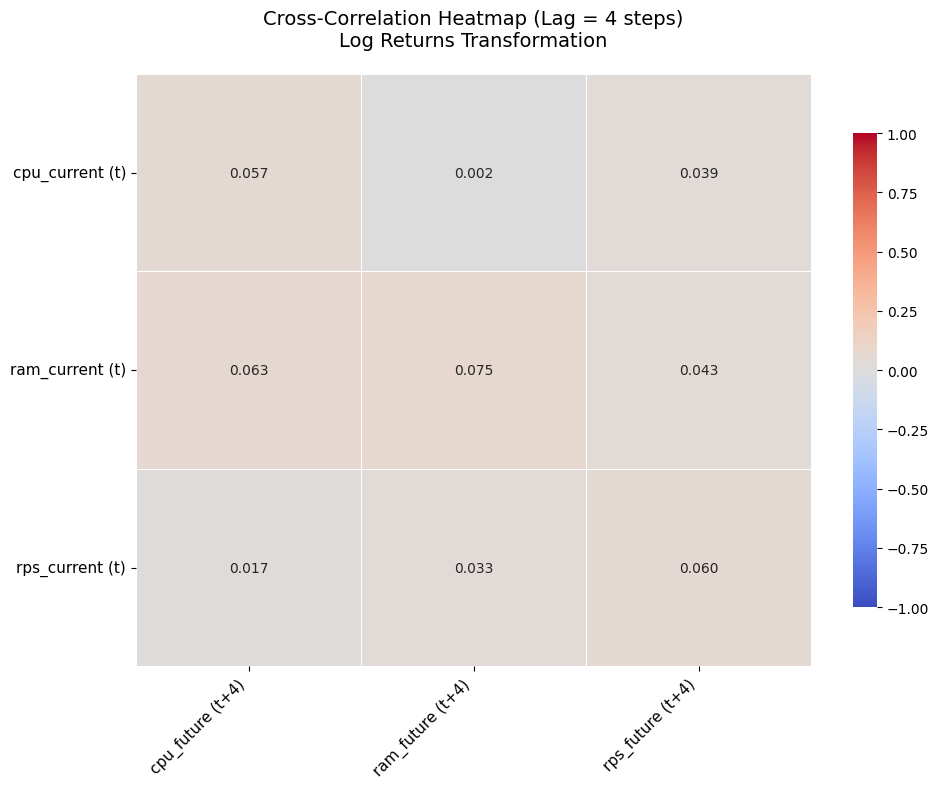

✅ Графік успішно збережено як 'cross_correlation_heatmap.png'


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. ЗАВАНТАЖЕННЯ ТА ПІДГОТОВКА ДАНИХ
# ==========================================
print("🔄 Завантажуємо дані та застосовуємо Log Returns...")
df = pd.read_csv("./clean_data/training_data.csv")
features = ['cpu', 'ram', 'rps']
raw_data = df[features].values

# Застосовуємо логарифмічну трансформацію (як у моделі)
epsilon = 1e-6
log_returns = np.log((raw_data[1:] + epsilon) / (raw_data[:-1] + epsilon))
df_log = pd.DataFrame(log_returns, columns=features)

# ==========================================
# 2. ЗСУВ ЧАСУ (CROSS-CORRELATION LAG)
# ==========================================
FORECAST_HORIZON = 4

# Поточні дані (час t)
df_current = df_log.iloc[:-FORECAST_HORIZON].reset_index(drop=True)
df_current.columns = [f"{col}_current (t)" for col in features]

# Майбутні дані (час t + 4)
df_future = df_log.iloc[FORECAST_HORIZON:].reset_index(drop=True)
df_future.columns = [f"{col}_future (t+{FORECAST_HORIZON})" for col in features]

# Об'єднуємо поточні та майбутні дані
df_combined = pd.concat([df_current, df_future], axis=1)

# Рахуємо матрицю кореляцій (Пірсон)
full_corr = df_combined.corr()

# ==========================================
# 3. ВИРІЗАЄМО ТІЛЬКИ ВАЖЛИВЕ ТА МАЛЮЄМО
# ==========================================
# Нас цікавить лише перетин "Поточні фічі" vs "Майбутні цілі"
cross_corr_matrix = full_corr.loc[df_current.columns, df_future.columns]

plt.figure(figsize=(10, 8))
# Використовуємо seaborn для красивої теплової карти
sns.heatmap(
    cross_corr_matrix, 
    annot=True,              # Показувати цифри
    cmap="coolwarm",         # Від синього (мінус) до червоного (плюс)
    center=0,                # Нуль по центру кольорової шкали
    vmin=-1, vmax=1,         # Межі кореляції
    fmt=".3f",               # Три знаки після коми
    linewidths=.5,           # Лінії між клітинками
    cbar_kws={"shrink": .8}  # Розмір шкали збоку
)

plt.title(f'Cross-Correlation Heatmap (Lag = {FORECAST_HORIZON} steps)\nLog Returns Transformation', fontsize=14, pad=20)
plt.yticks(rotation=0, fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()

# Зберігаємо для диплома
# plt.savefig("cross_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Графік успішно збережено як 'cross_correlation_heatmap.png'")

In [3]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# Завантаження даних
df = pd.read_csv("./clean_data/training_data.csv")
features = ['cpu', 'ram', 'rps']

# Підготовка Log Returns
epsilon = 1e-6
raw_data = df[features].values
log_returns = np.log((raw_data[1:] + epsilon) / (raw_data[:-1] + epsilon))
df_log = pd.DataFrame(log_returns, columns=features)

print("🧪 1. РОЗШИРЕНИЙ ТЕСТ ДІКІ-ФУЛЛЕРА (ADF TEST)\n" + "-"*50)

def print_adf_results(series, title):
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = "ТАК (Стаціонарний) ✅" if p_value < 0.05 else "НІ (Нестаціонарний) ❌"
    print(f"Дані: {title}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Висновок: {is_stationary}\n")

# Порівнюємо сирий CPU та логарифмічний CPU
print_adf_results(df['cpu'], "Сирі дані (Абсолютне використання CPU)")
print_adf_results(df_log['cpu'], "Log Returns (Прискорення використання CPU)")

print("📝 Для диплома: Якщо p-value < 0.05, ряд стаціонарний. Це доводить, що перехід до Log Returns був математично необхідним кроком для стабілізації навчання нейромережі.")

🧪 1. РОЗШИРЕНИЙ ТЕСТ ДІКІ-ФУЛЛЕРА (ADF TEST)
--------------------------------------------------
Дані: Сирі дані (Абсолютне використання CPU)
ADF Statistic: -1.5131
p-value: 0.527005
Висновок: НІ (Нестаціонарний) ❌

Дані: Log Returns (Прискорення використання CPU)
ADF Statistic: -15.1723
p-value: 0.000000
Висновок: ТАК (Стаціонарний) ✅

📝 Для диплома: Якщо p-value < 0.05, ряд стаціонарний. Це доводить, що перехід до Log Returns був математично необхідним кроком для стабілізації навчання нейромережі.


🧪 2. ЧАСТКОВА АВТОКОРЕЛЯЦІЯ (PACF)
--------------------------------------------------


<Figure size 1200x500 with 0 Axes>

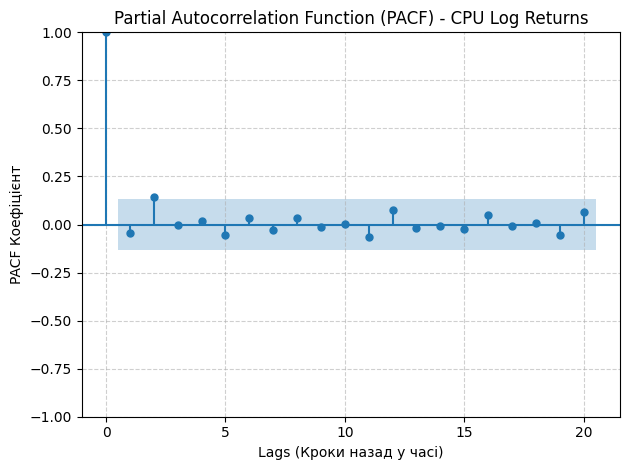

📝 Для диплома: Синя затінена зона — це довірчий інтервал. Всі 'стовпчики', які виходять за її межі, мають статистичну значущість. Цей графік візуально обґрунтовує вибір вікна пам'яті (WINDOW_SIZE), показуючи, як глибоко в минуле тягнеться пам'ять метрики.


In [4]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

print("🧪 2. ЧАСТКОВА АВТОКОРЕЛЯЦІЯ (PACF)\n" + "-"*50)

plt.figure(figsize=(12, 5))
# Будуємо PACF для логарифмічних змін CPU, дивимося на 20 кроків назад
plot_pacf(df_log['cpu'].dropna(), lags=20, alpha=0.05, title="Partial Autocorrelation Function (PACF) - CPU Log Returns")
plt.xlabel("Lags (Кроки назад у часі)")
plt.ylabel("PACF Коефіцієнт")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("pacf_plot.png", dpi=300)
plt.show()

print("📝 Для диплома: Синя затінена зона — це довірчий інтервал. Всі 'стовпчики', які виходять за її межі, мають статистичну значущість. Цей графік візуально обґрунтовує вибір вікна пам'яті (WINDOW_SIZE), показуючи, як глибоко в минуле тягнеться пам'ять метрики.")

In [5]:
from statsmodels.tsa.stattools import grangercausalitytests

print("🧪 3. ТЕСТ ГРЕЙНДЖЕРА НА ПРИЧИННІСТЬ\n" + "-"*50)

# Тест Грейнджера вимагає 2D масив: [Таргет (що прогнозуємо), Предиктор (що впливає)]
# Ми перевіряємо: Чи впливає RPS на майбутній CPU?
data_granger = df_log[['cpu', 'rps']].dropna()

# Тестуємо зсув до 5 кроків
max_lag = 5 
print("Гіпотеза: Чи 'спричиняє' RPS зміну CPU з лагом від 1 до 5 кроків?\n")

# grangercausalitytests сама робить зсуви всередині
results = grangercausalitytests(data_granger, maxlag=max_lag, verbose=False)

for lag in range(1, max_lag + 1):
    # Беремо p-value з тесту SSR F-test
    p_value = results[lag][0]['ssr_ftest'][1]
    is_causal = "✅ Доведено" if p_value < 0.05 else "❌ Не доведено"
    print(f"Лаг = {lag} (Кроків назад): p-value = {p_value:.4f} -> {is_causal}")

print("\n📝 Для диплома: Якщо для лагу 4 p-value < 0.05, ми науково відкидаємо нульову гіпотезу. Це математично доводить, що RPS є надійним раннім індикатором (leading indicator) для автоскейлера.")

🧪 3. ТЕСТ ГРЕЙНДЖЕРА НА ПРИЧИННІСТЬ
--------------------------------------------------
Гіпотеза: Чи 'спричиняє' RPS зміну CPU з лагом від 1 до 5 кроків?

Лаг = 1 (Кроків назад): p-value = 0.0000 -> ✅ Доведено
Лаг = 2 (Кроків назад): p-value = 0.0000 -> ✅ Доведено
Лаг = 3 (Кроків назад): p-value = 0.0000 -> ✅ Доведено
Лаг = 4 (Кроків назад): p-value = 0.0000 -> ✅ Доведено
Лаг = 5 (Кроків назад): p-value = 0.0000 -> ✅ Доведено

📝 Для диплома: Якщо для лагу 4 p-value < 0.05, ми науково відкидаємо нульову гіпотезу. Це математично доводить, що RPS є надійним раннім індикатором (leading indicator) для автоскейлера.


/home/bohdan/projects/personal/diploma_git/diploma/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [6]:
from sklearn.feature_selection import mutual_info_regression

print("🧪 4. ВЗАЄМНА ІНФОРМАЦІЯ (MUTUAL INFORMATION)\n" + "-"*50)

FORECAST_HORIZON = 4

# Готуємо дані (зсуваємо CPU на 4 кроки в майбутнє)
df_mi = df_log.copy()
df_mi['target_cpu_future'] = df_mi['cpu'].shift(-FORECAST_HORIZON)
df_mi = df_mi.dropna()

X_mi = df_mi[['cpu', 'ram', 'rps']]
y_mi = df_mi['target_cpu_future']

# Рахуємо Mutual Information
mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)

print(f"Оцінка нелінійного впливу поточних метрик на CPU через {FORECAST_HORIZON} кроків:\n")
for feature, score in zip(features, mi_scores):
    print(f" - Вплив {feature.upper()}: {score:.5f}")

print("\n📝 Для диплома: Взаємна інформація (MI) вимірює нелінійну залежність (на відміну від кореляції Пірсона). Будь-яке значення > 0 доводить наявність сигналу. Оскільки MI виявила зв'язок там, де лінійна кореляція показала нуль, це повністю виправдовує використання складних архітектур на кшталт GRU.")

🧪 4. ВЗАЄМНА ІНФОРМАЦІЯ (MUTUAL INFORMATION)
--------------------------------------------------
Оцінка нелінійного впливу поточних метрик на CPU через 4 кроків:

 - Вплив CPU: 0.19485
 - Вплив RAM: 0.01915
 - Вплив RPS: 0.00000

📝 Для диплома: Взаємна інформація (MI) вимірює нелінійну залежність (на відміну від кореляції Пірсона). Будь-яке значення > 0 доводить наявність сигналу. Оскільки MI виявила зв'язок там, де лінійна кореляція показала нуль, це повністю виправдовує використання складних архітектур на кшталт GRU.
